# 

# EDA

Primero hacemos los imports necesarios unicamente para el EDA:

In [201]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import FunctionTransformer
import random

La configuración de nuestro notebook consiste en SEMILLA (Uno de los dos NIAS) y el archivo de datos

In [202]:
SEMILLA = 100522258
ARCHIVO_DATOS = '../data/bank_13.pkl'
np.random.seed(SEMILLA)
random.seed(SEMILLA)

Ahora cargamos los datos de nuestro archivo y realizamos una pequeña visualización de los primeros 

In [203]:
df = pd.read_pickle(ARCHIVO_DATOS)
print(f"Dimensiones: {df.shape}")
df.head()

Dimensiones: (11000, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


Necesitamos analizar que variables son categóricas, cuales numericas y también utilizaremos una tabla con los nulos, valores unívocos y el tipo de cada una

In [204]:
print("Análisis de Variables\n")
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df.select_dtypes(include=['number']).columns.tolist()
print(f"Numéricas ({len(num_cols)}): {num_cols}")
print(f"Categóricas ({len(cat_cols)}): {cat_cols}")
summary = pd.DataFrame({
    'nulos': df.isnull().sum(),
    'unicos': df.nunique(),
    'tipo': df.dtypes
})
print("\nResumen de columnas:")
print(summary)

Análisis de Variables

Numéricas (7): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categóricas (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']

Resumen de columnas:
           nulos  unicos    tipo
age            0      76   int64
job            0      12  object
marital      406       3  object
education      0       4  object
default        0       2  object
balance        0    3783   int64
housing        0       2  object
loan           0       2  object
contact        0       3  object
day            0      31   int64
month          0      12  object
duration       0    1423   int64
campaign       0      36   int64
pdays          0     472   int64
previous       0      34   int64
poutcome       0       4  object
deposit        0       2  object


Vemos que los valores nulos son relativamente pocos en relación al número de instancias que tenemos en el dataset, por lo que la imputación posterior quizás no sea tan ventajosa

Ahora vamos a comprobar la cardinalidad de las columnas categóricas, si hay alguna con valores constantes y si hay columnas identificadoras.
También veremos si el problema es de regresión o clasificación y si es binaria, junto al balanceo de clases y la columna p_days que es de especial interés.

In [205]:
print("\nALTA CARDINALIDAD")
for col in df.columns.tolist():
    n = df[col].nunique()
    if n > 10:
        print(f"{col}: {n} valores únicos, la cardinalidad es alta")
    else:
        print(f"{col}: {n} valores")

print("\nCOLUMNAS CONSTANTES")
const_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"Constantes: {const_cols if const_cols else 'Ninguna'}")

print("\nPOSIBLES COLUMNAS ID")
found = False
for col in df.columns:
    if df[col].nunique() == len(df):
        print(f"{col}: todos los valores únicos")
if not found:
    print("No hay columnas id")

print("\nTIPO DE PROBLEMA")
variable_objetivo = 'deposit'
if df[variable_objetivo].nunique()>2:
    print("El problema no es de clasificación binaria")
else:
    print("El problema es de clasificación binaria")

print("\nBALANCEO DE CLASES")
balance = df['deposit'].value_counts(normalize=True)
print(balance)
umbral_desbalanceo = 0.3
if balance.min() < umbral_desbalanceo:
    print("El dataset está desbalanceado")
else:
    print("El dataset está balanceado\n")

print("ANÁLISIS ESPECÍFICO DE 'pdays':\n")
print(f"Valores únicos: {df['pdays'].nunique()}\n")
print(f"Valor -1 (nunca contactado): {(df['pdays'] == -1).sum()} ({((df['pdays'] == -1).sum()/len(df))*100:.1f}%)\n")

print("Matriz de correlación sólo para pdays con respecto a las otras variables")
corr_matrix = df[num_cols].corr()
print(corr_matrix['pdays'].sort_values(ascending=False))


ALTA CARDINALIDAD
age: 76 valores únicos, la cardinalidad es alta
job: 12 valores únicos, la cardinalidad es alta
marital: 3 valores
education: 4 valores
default: 2 valores
balance: 3783 valores únicos, la cardinalidad es alta
housing: 2 valores
loan: 2 valores
contact: 3 valores
day: 31 valores únicos, la cardinalidad es alta
month: 12 valores únicos, la cardinalidad es alta
duration: 1423 valores únicos, la cardinalidad es alta
campaign: 36 valores únicos, la cardinalidad es alta
pdays: 472 valores únicos, la cardinalidad es alta
previous: 34 valores únicos, la cardinalidad es alta
poutcome: 4 valores
deposit: 2 valores

COLUMNAS CONSTANTES
Constantes: Ninguna

POSIBLES COLUMNAS ID
No hay columnas id

TIPO DE PROBLEMA
El problema es de clasificación binaria

BALANCEO DE CLASES
deposit
no     0.525455
yes    0.474545
Name: proportion, dtype: float64
El dataset está balanceado

ANÁLISIS ESPECÍFICO DE 'pdays':

Valores únicos: 472

Valor -1 (nunca contactado): 8203 (74.6%)

Matriz de c

In [206]:
for feature in cat_cols:
    print(df[feature].value_counts())

job
management       2520
blue-collar      1917
technician       1791
admin.           1317
services          916
retired           774
self-employed     399
student           359
unemployed        347
entrepreneur      322
housemaid         270
unknown            68
Name: count, dtype: int64
marital
married     6047
single      3303
divorced    1244
Name: count, dtype: int64
education
secondary    5393
tertiary     3630
primary      1483
unknown       494
Name: count, dtype: int64
default
no     10833
yes      167
Name: count, dtype: int64
housing
no     5801
yes    5199
Name: count, dtype: int64
loan
no     9569
yes    1431
Name: count, dtype: int64
contact
cellular     7922
unknown      2309
telephone     769
Name: count, dtype: int64
month
may    2780
aug    1500
jul    1495
jun    1205
nov     930
apr     905
feb     763
oct     387
jan     342
sep     313
mar     271
dec     109
Name: count, dtype: int64
poutcome
unknown    8205
failure    1208
success    1059
other       528
Nam

Gracias a esta información sabemos que
- El dataset está balanceado, lo que nos facilita el trabajo ya que no habrá que hacer oversampling
- Hay columnas con alta cardinalidad
- No hay columnas identificadoras, lo que nos facilita el trabajo con árboles ya que no habrá que tener en cuenta un alto factor de branching en ningún atributo de forma innecesaria
- P_days tiene un alto porcentaje de gente que nunca ha pagado y no está muy correlacionada con ninguna otra columna, por lo que sacaremos una nueva feature que sea nunca contactado.

Vamos a analizar la relación que tiene pdays con la variable objetivo para obtener un poco más de información

ANÁLISIS ESPECÍFICO DE 'pdays'
Valores únicos en pdays: 472
Valor -1 (nunca contactado): 8203 instancias (74.6%)
Estadísticos excluyendo -1:
  - Min: 1
  - Max: 854
  - Media: 204.7
  - Mediana: 182.0
nunca_contactado
1    8203
0    2797
Name: count, dtype: int64


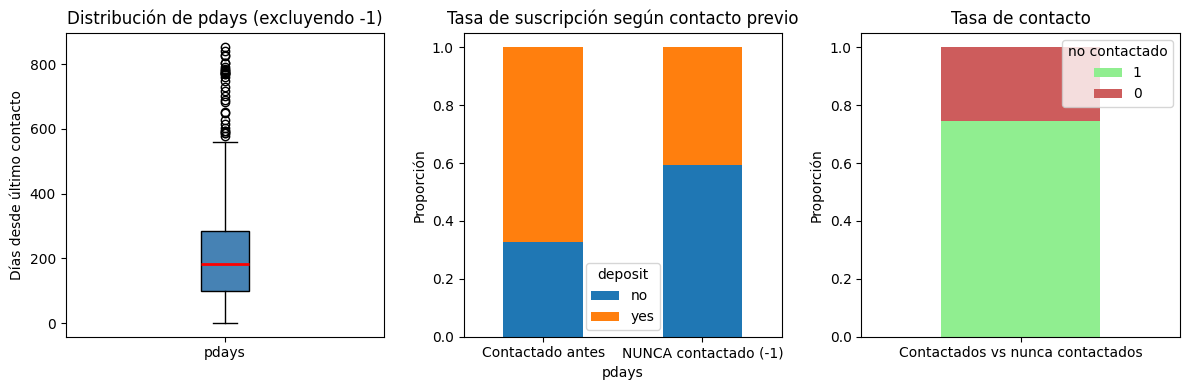

Correlación de la columna pdays con el target

0.15312052432102163

Correlación de la columna pdays (sólo para cuando no se le ha contactado)

-0.23190827436671366


In [207]:
print("ANÁLISIS ESPECÍFICO DE 'pdays'")

print(f"Valores únicos en pdays: {df['pdays'].nunique()}")
print(f"Valor -1 (nunca contactado): {(df['pdays'] == -1).sum()} instancias ({((df['pdays'] == -1).sum()/len(df))*100:.1f}%)")
print(f"Estadísticos excluyendo -1:")
pdays_positivos = df[df['pdays'] != -1]['pdays']
print(f"  - Min: {pdays_positivos.min()}")
print(f"  - Max: {pdays_positivos.max()}")
print(f"  - Media: {pdays_positivos.mean():.1f}")
print(f"  - Mediana: {pdays_positivos.median()}")

df_corr = df.copy()
df_corr['deposit'] = df_corr['deposit'].map({'yes': 1, 'no': 0})
df_corr['nunca_contactado'] = (df['pdays'] == -1).astype(int)

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Boxplot de pdays (excluyendo -1) - REEMPLAZA AL HISTOGRAMA
axes[0].boxplot(pdays_positivos, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='black'),
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Distribución de pdays (excluyendo -1)')
axes[0].set_ylabel('Días desde último contacto')
axes[0].set_xticklabels(['pdays'])

# Relación con target (este se mantiene igual)
pd.crosstab(df['pdays'] == -1, df['deposit'], normalize='index').plot(
    kind='bar', ax=axes[1], stacked=True)
axes[1].set_title('Tasa de suscripción según contacto previo')
axes[1].set_xticklabels(['Contactado antes', 'NUNCA contactado (-1)'], rotation=0)
axes[1].set_ylabel('Proporción')
axes[1].legend(title='deposit')
print(df_corr['nunca_contactado'].value_counts())
df_corr['nunca_contactado'].value_counts(normalize=True).to_frame().T.plot(kind='bar', color=['lightgreen', 'indianred'], ax=axes[2], stacked=True)
axes[2].set_title('Tasa de contacto')
axes[2].set_ylabel('Proporción')
axes[2].set_xticklabels(['Contactados vs nunca contactados'], rotation=0)
axes[2].legend(title='no contactado')

plt.tight_layout()
plt.show()

print("Correlación de la columna pdays con el target\n")
target_corr = df_corr['deposit'].corr(df_corr['pdays'])
print(f"{target_corr}")

print("\nCorrelación de la columna pdays (sólo para cuando no se le ha contactado)\n")
target_corr = df_corr['deposit'].corr(df_corr['nunca_contactado'])
print(f"{target_corr}")

Como podemos ver, la variable pdays es irrelevante en comparación con la feature derivada nunca_contactado. Además al tener alta cardinalidad realentizará el proceso de entrenamiento de nuestros modelos, especialmente en el caso de los árboles, por lo que deberíamos eliminarlo.

## Preproceso
Con la eliminación de la columna pdays así como la creación de la nueva feature empezamos la etapa de preproceso.
para esto vamos a usar funciones para poder incluirlas en la pipeline final

# 

In [208]:
def crear_nunca_contactado_eliminar_pdays(df):
    df_copy = df.copy()
    df_copy["nunca_contactado"] = (df_copy['pdays'] == -1).astype(int)
    df_copy = df_copy.drop('pdays', axis=1)
    return df_copy
preproceso_de_pdays = FunctionTransformer(crear_nunca_contactado_eliminar_pdays)
new_df = crear_nunca_contactado_eliminar_pdays(df)

## Separación de variables

Separamos features (X) y target (y), y dividimos en train/test con holdout 2/3 - 1/3.

In [209]:
from sklearn.model_selection import train_test_split

X = df.drop('deposit', axis=1)
y = df['deposit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=SEMILLA, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (7333, 16), Test: (3667, 16)


In [210]:
# Convertir target a numérico para todos los modelos
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)  # 'no' -> 0, 'yes' -> 1
y_test = le.transform(y_test)

print(f"Clases después de conversión: 0={sum(y_train==0)} ({100*sum(y_train==0)/len(y_train):.1f}%), 1={sum(y_train==1)} ({100*sum(y_train==1)/len(y_train):.1f}%)")
print(f"Mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Clases después de conversión: 0=3853 (52.5%), 1=3480 (47.5%)
Mapping: {'no': np.int64(0), 'yes': np.int64(1)}


## Identificación de tipos de variables

In [211]:
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_features.remove("pdays")
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numéricas: {numeric_features}")
print(f"Categóricas: {categorical_features}")

Numéricas: ['age', 'balance', 'day', 'duration', 'campaign', 'previous']
Categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


## Comparación de escaladores para KNN

Evaluamos MinMaxScaler, StandardScaler y RobustScaler para determinar el más adecuado.

In [212]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

scalers = {
    'minmax': MinMaxScaler(),
    'standard': StandardScaler(),
    'robust': RobustScaler()
}
print(numeric_features)


['age', 'balance', 'day', 'duration', 'campaign', 'previous']


In [213]:
knn_results = {}
for name, scaler in scalers.items():
    pipeline = Pipeline([
        ('pdays', preproceso_de_pdays),
        ('preprocessor', ColumnTransformer([
            ('num', scaler, numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
        ])),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ])
    
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1_macro')
    knn_results[name] = scores.mean()
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

best_scaler = max(knn_results, key=knn_results.get)
print(f"\n✅ Mejor escalador: {best_scaler}")


minmax: 0.7290 (+/- 0.0071)
standard: 0.8032 (+/- 0.0100)
robust: 0.7939 (+/- 0.0055)

✅ Mejor escalador: standard


## Modelo baseline (Dummy)

Para comparar si nuestros modelos aportan valor.

In [214]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
baseline_f1 = f1_score(y_test, dummy_pred, average='macro')

print(f"Baseline F1-macro: {baseline_f1:4f}")

Baseline F1-macro: 0.344476


## KNN y Decision Tree con hiperparámetros por defecto

In [215]:
import time
from sklearn.tree import DecisionTreeClassifier

# KNN default
knn_default = Pipeline([
    ('pdays', preproceso_de_pdays),
    ('preprocessor', ColumnTransformer([
        ('num', scalers[best_scaler], numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])),
    ('knn', KNeighborsClassifier())
])

start = time.time()
knn_default.fit(X_train, y_train)
knn_time = time.time() - start
knn_pred = knn_default.predict(X_test)
knn_f1 = f1_score(y_test, knn_pred, average='macro')

print(f"KNN default - Tiempo: {knn_time:.3f}s, F1-macro: {knn_f1:.4f}")
print(f"Tiempo de entrenamiento de KNN: {knn_time} segundos")

# Decision Tree default
dt_default = Pipeline([
    ('pdays', preproceso_de_pdays),
    ('preprocessor', ColumnTransformer([
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])),
    ('dt', DecisionTreeClassifier(random_state=SEMILLA))
])

start = time.time()
dt_default.fit(X_train, y_train)
dt_time = time.time() - start
dt_pred = dt_default.predict(X_test)
dt_f1 = f1_score(y_test, dt_pred, average='macro')

print(f"DT default - Tiempo: {dt_time:.3f}s, F1-macro: {dt_f1:.4f}")
print(f"Tiempo de entrenamiento de DT: {dt_time} segundos")

KNN default - Tiempo: 0.013s, F1-macro: 0.7938
Tiempo de entrenamiento de KNN: 0.01347041130065918 segundos
DT default - Tiempo: 0.052s, F1-macro: 0.7917
Tiempo de entrenamiento de DT: 0.05180168151855469 segundos


## Árbol poco profundo para interpretación (max_depth=3)

['age', 'balance', 'day', 'duration', 'campaign', 'previous', 'nunca_contactado'] ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


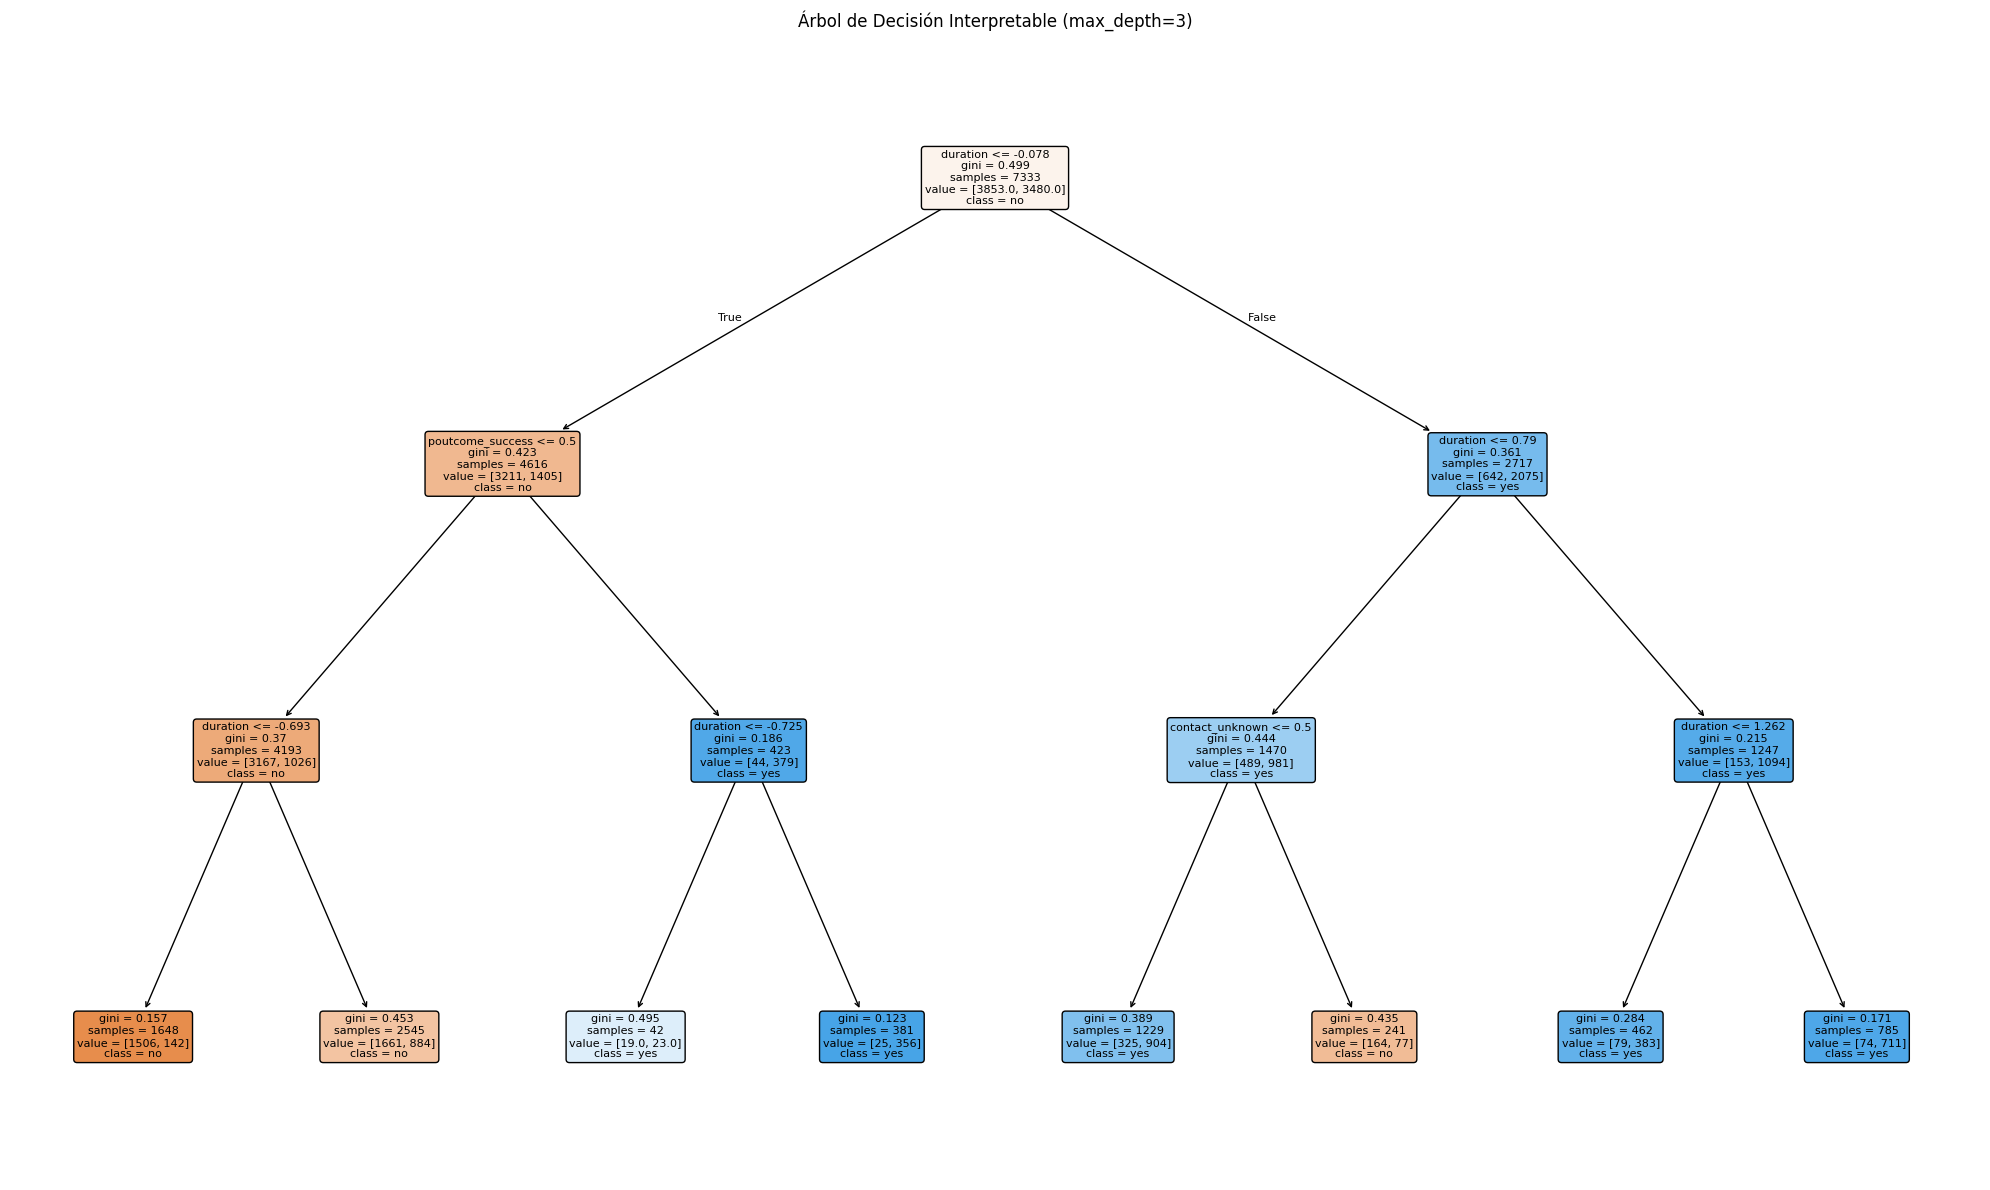

In [216]:
if "nunca_contactado" not in numeric_features:
    numeric_features.append("nunca_contactado")
print(numeric_features, categorical_features)
shallow_tree = Pipeline([
    ('pdays', preproceso_de_pdays),
    ('preprocessor', ColumnTransformer([
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])),
    ('dt', DecisionTreeClassifier(max_depth=3, random_state=SEMILLA))
])

shallow_tree.fit(X_train, y_train)
# Obtener nombres de features
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train[categorical_features])
feature_names = numeric_features + list(ohe.get_feature_names_out(categorical_features))

plt.figure(figsize=(20, 12))
from sklearn.tree import plot_tree
plot_tree(shallow_tree.named_steps['dt'], 
          feature_names=feature_names,
          class_names=['no', 'yes'],
          filled=True,
          rounded=True,
          fontsize=8)
plt.title("Árbol de Decisión Interpretable (max_depth=3)")
plt.tight_layout()
plt.show()

## Optimización de hiperparámetros (HPO)

In [217]:
from sklearn.model_selection import GridSearchCV

# KNN HPO
knn_pipe = Pipeline([
    ('pdays', preproceso_de_pdays),
    ('preprocessor', ColumnTransformer([
        ('num', scalers[best_scaler], numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])),
    ('knn', KNeighborsClassifier())
])

knn_params = {
    'knn__n_neighbors': [3, 5, 7, 11, 15, 21],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]
}

knn_grid = GridSearchCV(knn_pipe, knn_params, cv=5, scoring='f1_macro', n_jobs=-1)
start = time.time()
knn_grid.fit(X_train, y_train)
knn_hpo_time = time.time() - start

print(f"KNN HPO - Mejores params: {knn_grid.best_params_}")
print(f"KNN HPO - Tiempo: {knn_hpo_time:.2f} segundos")
print(f"KNN HPO - F1-test: {f1_score(y_test, knn_grid.predict(X_test), average='macro'):.4f}")

# Decision Tree HPO
dt_pipe = Pipeline([
    ('pdays', preproceso_de_pdays),
    ('preprocessor', ColumnTransformer([
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])),
    ('dt', DecisionTreeClassifier(random_state=SEMILLA))
])

dt_params = {
    'dt__max_depth': [3, 5, 7, 10, 15, None],
    'dt__min_samples_split': [2, 5, 10, 20],
    'dt__min_samples_leaf': [1, 2, 5, 10]
}

dt_grid = GridSearchCV(dt_pipe, dt_params, cv=5, scoring='f1_macro', n_jobs=-1)
start = time.time()
dt_grid.fit(X_train, y_train)
dt_hpo_time = time.time() - start

print(f"DT HPO - Mejores params: {dt_grid.best_params_}")
print(f"DT HPO - Tiempo: {dt_hpo_time:.2f} segundos")
print(f"DT HPO - F1-test: {f1_score(y_test, dt_grid.predict(X_test), average='macro'):.4f}")

KNN HPO - Mejores params: {'knn__n_neighbors': 7, 'knn__p': 2, 'knn__weights': 'distance'}
KNN HPO - Tiempo: 3.81 segundos
KNN HPO - F1-test: 0.8005
DT HPO - Mejores params: {'dt__max_depth': 10, 'dt__min_samples_leaf': 5, 'dt__min_samples_split': 20}
DT HPO - Tiempo: 2.13 segundos
DT HPO - F1-test: 0.8349


## Modelos lineales y SVM

### Regresión logística
Ahora vamos a entrenar una regresión logística con los datos disponibles usando Elastic Net y HPO para encontrar la mejor combinación

In [218]:
from sklearn.linear_model import LogisticRegression
print("\nOptimizando Logistic Regression con ElasticNet...")

lr_pipe = Pipeline([
    ('pdays', preproceso_de_pdays),
    ('preprocessor', ColumnTransformer([
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])),
    ('lr', LogisticRegression(
        random_state=SEMILLA, 
        max_iter=1000, 
        solver='saga',           # Necesario para ElasticNet
        tol=1e-3                 # Tolerancia para convergencia más rápida
    ))
])

# Parámetros: C (inverso de regularización) y l1_ratio (mezcla L1/L2)
lr_params = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__l1_ratio': [0, 0.3, 0.5, 0.7, 1]  # 0=L2, 1=L1, intermedios=ElasticNet
}

# Suprimir warnings específicos de convergencia
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.linear_model')

lr_grid = GridSearchCV(lr_pipe, lr_params, cv=5, scoring='f1_macro', n_jobs=-1, verbose=0)
start = time.time()
lr_grid.fit(X_train, y_train)
lr_hpo_time = time.time() - start

best_l1_ratio = lr_grid.best_params_['lr__l1_ratio']
best_C = lr_grid.best_params_['lr__C']
best_score = lr_grid.best_score_

print(f"LR HPO (ElasticNet) - Mejores params: C={best_C}, l1_ratio={best_l1_ratio}")
print(f"  → l1_ratio={best_l1_ratio}: ", end="")
if best_l1_ratio == 0:
    print("Ridge (L2) - No elimina coeficientes")
elif best_l1_ratio == 1:
    print("Lasso (L1) - Elimina coeficientes (sparse)")
else:
    print(f"ElasticNet - Mezcla L1({best_l1_ratio}) y L2({1-best_l1_ratio})")
print(f"LR HPO - Mejor F1-macro (CV): {best_score:.4f}")
print(f"LR HPO - Tiempo: {lr_hpo_time:.2f} segundos")

y_pred_lr = lr_grid.predict(X_test)
lr_best_f1 = f1_score(y_test, y_pred_lr, average='macro')
print(f"Tiempo de entrenamiento de LR HPO - F1-test: {lr_best_f1:.4f} segundos")


Optimizando Logistic Regression con ElasticNet...
LR HPO (ElasticNet) - Mejores params: C=100, l1_ratio=0
  → l1_ratio=0: Ridge (L2) - No elimina coeficientes
LR HPO - Mejor F1-macro (CV): 0.8341
LR HPO - Tiempo: 5.65 segundos
Tiempo de entrenamiento de LR HPO - F1-test: 0.8286 segundos


## Atributos más relevantes (Logistic Regression)
Vamos a echar un vistazo a los mejores atributos según la regresión logística óptima encontrada:

In [219]:
best_lr = lr_grid.best_estimator_
coefs = best_lr.named_steps['lr'].coef_[0]

preproc = best_lr.named_steps['preprocessor']
ohe_features = preproc.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_features = numeric_features + list(ohe_features)

importance = pd.DataFrame({'feature': all_features, 'coef': coefs, 'abs_coef': np.abs(coefs)})
importance = importance.sort_values('abs_coef', ascending=False).head(10)

print("Top 10 atributos más relevantes:")
print(importance[['feature', 'coef']].to_string(index=False))

Top 10 atributos más relevantes:
         feature      coef
    marital_None  3.982835
       month_mar  2.024543
        duration  1.900576
poutcome_success  1.574540
       month_dec  1.436693
 marital_married -1.309935
       month_jan -1.297361
marital_divorced -1.211967
  marital_single -1.089589
       month_jul -1.052177


### SVM con HPO
Vamos a entrenar un modelo SVM encontrando los mejores hiperparámetros como hasta ahora

In [220]:
from sklearn.svm import SVC
svm_pipe = Pipeline([
    ('pdays', preproceso_de_pdays),
    ('preprocessor', ColumnTransformer([
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])),
    ('svm', SVC(random_state=SEMILLA, probability=True))
])

svm_params = {'svm__C': [0.1, 1, 10, 100], 'svm__gamma': ['scale', 'auto', 0.1, 1], 'svm__kernel': ['rbf', 'linear']}

svm_grid = GridSearchCV(svm_pipe, svm_params, cv=5, scoring='f1_macro', n_jobs=-1)
start = time.time()
svm_grid.fit(X_train, y_train)
svm_hpo_time = time.time() - start

print(f"SVM HPO - Mejores params: {svm_grid.best_params_}")
print(f"SVM HPO - F1-test: {f1_score(y_test, svm_grid.predict(X_test), average='macro'):.4f}")
print(f"SVM HPO - Tiempo de entrenamiento: {svm_hpo_time}")

SVM HPO - Mejores params: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
SVM HPO - F1-test: 0.8554
SVM HPO - Tiempo de entrenamiento: 257.04606437683105


## Selección del mejor modelo y evaluación final

     Modelo   F1-test
4       SVM  0.855446
2        DT  0.834877
3        LR  0.828608
1       KNN  0.800463
0  Baseline  0.344476

Accuracy: 0.8555
F1-macro: 0.8554


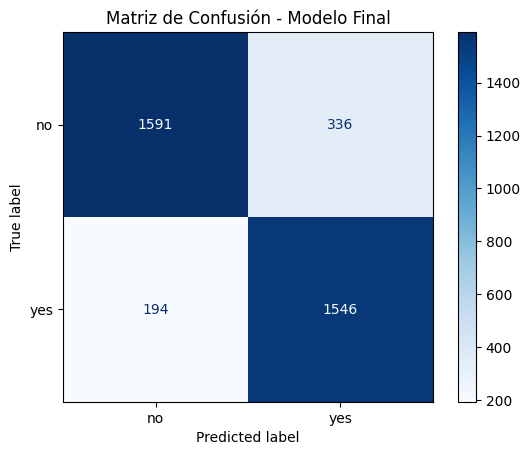

In [221]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, roc_auc_score, roc_curve, auc, ConfusionMatrixDisplay
# Comparativa
results = pd.DataFrame({
    'Modelo': ['Baseline', 'KNN', 'DT', 'LR', 'SVM'],
    'F1-test': [baseline_f1, 
                f1_score(y_test, knn_grid.predict(X_test), average='macro'),
                f1_score(y_test, dt_grid.predict(X_test), average='macro'),
                f1_score(y_test, lr_grid.predict(X_test), average='macro'),
                f1_score(y_test, svm_grid.predict(X_test), average='macro')]
})
print(results.sort_values('F1-test', ascending=False))

# Mejor modelo (asumiendo que SVM es el mejor, ajusta según tus resultados)
final_model = svm_grid.best_estimator_
y_pred = final_model.predict(X_test)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-macro: {f1_score(y_test, y_pred, average='macro'):.4f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['no', 'yes']).plot(cmap='Blues')
plt.title('Matriz de Confusión - Modelo Final')
plt.show()

## Guardar modelo final

In [222]:
import os
import joblib
os.makedirs('../models', exist_ok=True)
joblib.dump(final_model, '../models/modelo_final.joblib')
print("✅ Modelo guardado en '../models/modelo_final.joblib'")

✅ Modelo guardado en '../models/modelo_final.joblib'


## Tarea abierta: Curvas ROC

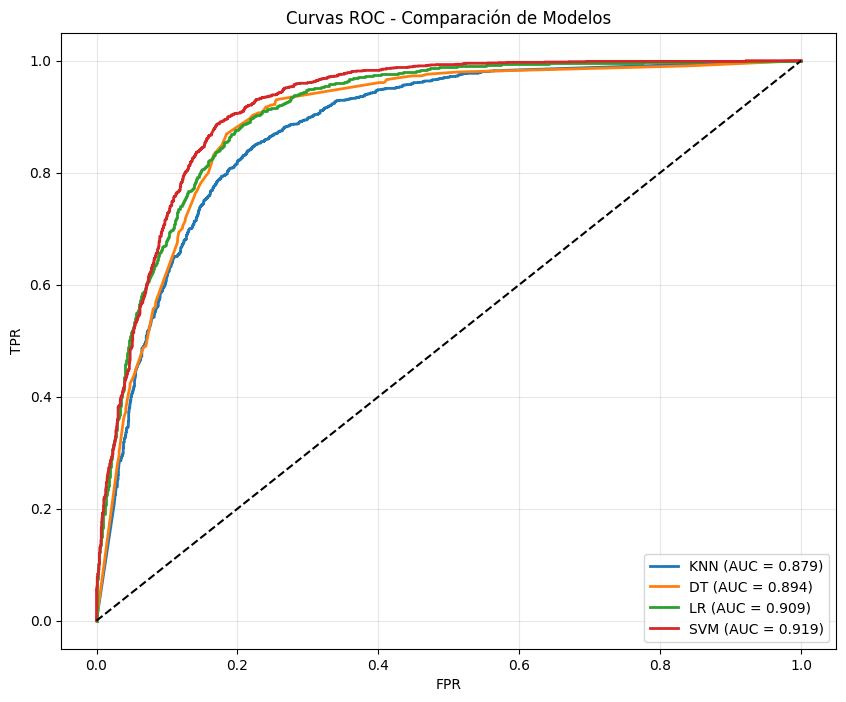

In [223]:
plt.figure(figsize=(10, 8))
y_test_bin = y_test

for name, model in [('KNN', knn_grid), ('DT', dt_grid), ('LR', lr_grid), ('SVM', svm_grid)]:
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_bin, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curvas ROC - Comparación de Modelos')
plt.legend()
plt.grid(alpha=0.3)
plt.show()